<a href="https://colab.research.google.com/github/Alenushka2013/ML_for_people_tasks/blob/main/HW_7_Computer_Vision_with_PyTorch_Excercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises. Solution


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

### Основні сфери застосування

Автономні системи
- Навігація для безпілотних автомобілів, дронів, роботів  
- Виявлення перешкод та об'єктів на дорозі  

Безпека та спостереження
- Розпізнавання облич для контролю доступу та ідентифікації  
- Виявлення підозрілих об'єктів, людей або порушень  
  (наприклад, розмиття номерних знаків)

Виробництво та промисловість
- Автоматичний контроль якості продукції на дефекти  
- Оптимізація виробничих процесів та безпеки праці  
- Керування роботами-маніпуляторами  

Медицина
- Аналіз медичних зображень (рентген, МРТ, УЗД) для діагностики  
- Раннє виявлення захворювань  
- Виявлення співробітників із підвищеною температурою  

Розумні міста
- Виявлення вибоїн на дорогах, управління вуличним освітленням  
- Виявлення незаконних звалищ  

Роздрібна торгівля та маркетинг
- Аналіз поведінки покупців (відстеження погляду)  
- Персоналізація реклами  

Мобільні додатки та розваги
- Розпізнавання об'єктів, наприклад, вина за фотографією  
- Створення відеоефектів для кіно

## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

1. На перших шарах виділяються прості ознаки - краї, лінії, кути, контрастні переходи.

2. На середніх і глибоких шарах мережа виділяє тектури, форми, частини об'єктів.

3. На виході згорткових блоків формується набір ознак, який подається на повнозв'язні шари. Саме вони приймають рішення про класифікацію зображення.

## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [1]:
# Імпортуємо PyTorch
import torch
from torch import nn

# Імпортуємо torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Імпортуємо matplotlib для візуалізації
import matplotlib.pyplot as plt

In [2]:
# Налаштування навчальних даних
train_data = datasets.MNIST(
    root="data", # куди завантажити дані?
    train=True, # отримати навчальні дані
    download=True, # завантажити дані, якщо їх немає на диску
    transform=ToTensor(), # зображення приходять у форматі PIL, ми хочемо перетворити їх на тензори Torch
    target_transform=None # ви також можете перетворити мітки
)

# Налаштування тестових даних
test_data = datasets.MNIST(
    root="data",
    train=False, # отримати тестові дані
    download=True,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.7MB/s]


In [3]:
# скільки елементів в кожному наборі
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# Покажіть формат (розмірності) кожної картинки
image, label = train_data[0]
image.shape

torch.Size([1, 28, 28])

In [5]:
# які класи представлені в цьому наборі даних
train_data.targets.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [6]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

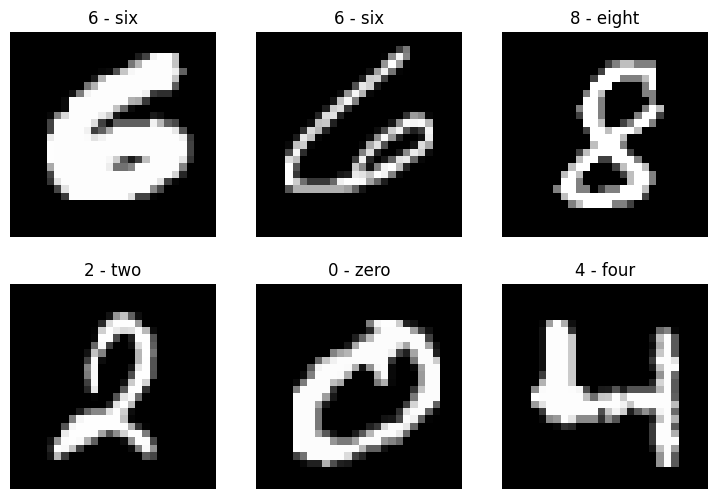

In [7]:
# Відобразити більше зображень
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 6))
rows, cols = 2, 3
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [8]:
from torch.utils.data import DataLoader

# Налаштування гіперпараметра розміру партії
BATCH_SIZE = 32

# Перетворення наборів даних на ітерабельні (партії)
train_dataloader = DataLoader(train_data, # набір даних, який потрібно перетворити на ітерабельний
    batch_size=BATCH_SIZE, # скільки зразків на партію?
    shuffle=True # перемішувати дані на кожній епосі?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # не обов'язково перемішувати тестові дані
)

# Давайте перевіримо, що ми створили
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Довжина навчального dataloader: {len(train_dataloader)} партій по {BATCH_SIZE}")
print(f"Довжина тестового dataloader: {len(test_dataloader)} партій по {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7b15f15c4f20>, <torch.utils.data.dataloader.DataLoader object at 0x7b15f2227d70>)
Довжина навчального dataloader: 1875 партій по 32
Довжина тестового dataloader: 313 партій по 32


## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [9]:
# Створення згорткової нейронної мережі
class ModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [11]:
# Вимірювання часу
import time

# Навчання та тестування моделі
def train_model_on_device(model, device, dataloader, epochs = 5):
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  model = model.to(device)

  for epoch in range(epochs):
      model.train()
      total_loss = 0

      for image, label in dataloader:
        image = image.to(device)
        label = label.to(device)

        label_pred = model(image)
        loss = loss_fn(label_pred, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
      print(f'Епоха: {epoch + 1}  Loss: {total_loss/len(dataloader):.4f}')

for device in ['cpu', 'cuda']:
  start_time = time.time()
  print(f'Training on {device.upper()}:')
  model_MNIST = ModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names))
  train_model_on_device(model_MNIST, device, train_dataloader)
  print(f'Total time: {time.time() - start_time:.3f} seconds')

Training on CPU:
Епоха: 1  Loss: 0.2405
Епоха: 2  Loss: 0.0707
Епоха: 3  Loss: 0.0573
Епоха: 4  Loss: 0.0488
Епоха: 5  Loss: 0.0427
Total time: 201.975 seconds
Training on CUDA:
Епоха: 1  Loss: 0.2267
Епоха: 2  Loss: 0.0730
Епоха: 3  Loss: 0.0562
Епоха: 4  Loss: 0.0472
Епоха: 5  Loss: 0.0424
Total time: 56.826 seconds


## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

In [12]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            pred_probs.append(pred_prob)

    return torch.stack(pred_probs)

In [13]:
import random

random.seed(13)
test_samples = []
test_labels = []

for k in range(9):
    sample_idx = random.randint(0, len(test_data) - 1)
    sample, label = test_data[sample_idx]
    test_samples.append(sample)
    test_labels.append(label)

device = next(model_MNIST.parameters()).device

pred_probs = make_predictions(model=model_MNIST,
                              data=test_samples,
                              device=device)

pred_classes = pred_probs.argmax(dim=1)

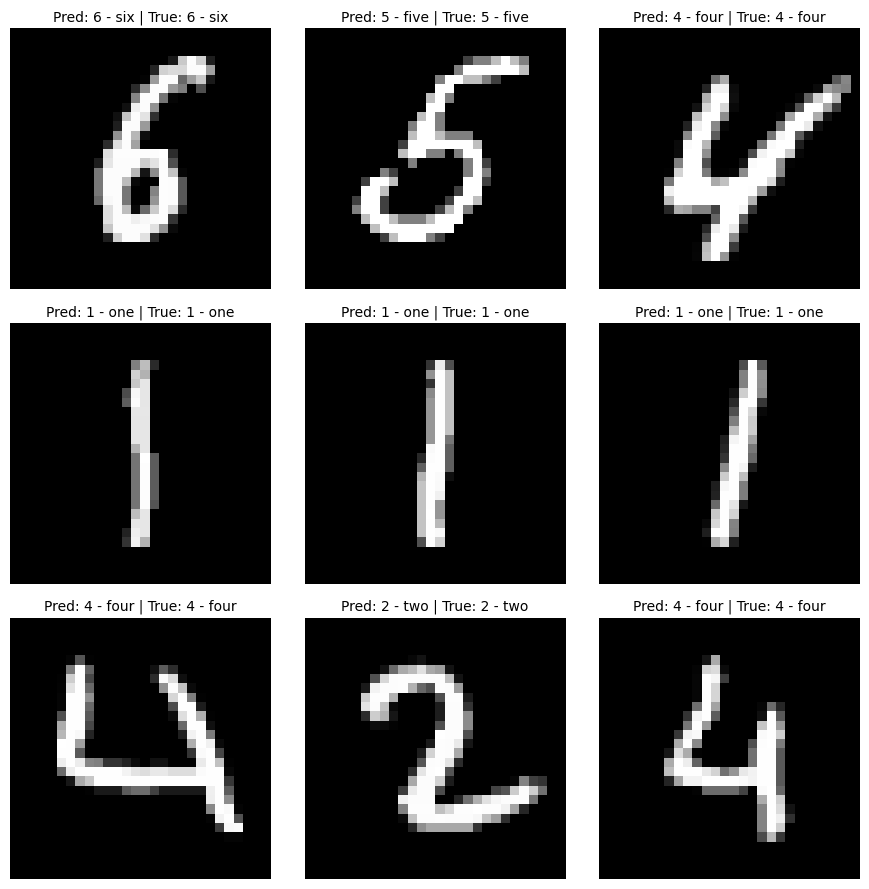

In [14]:
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):

  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze(), cmap="gray")

  pred_label = class_names[pred_classes[i]]
  truth_label = class_names[test_labels[i]]

  title_text = f"Pred: {pred_label} | True: {truth_label}"
  plt.title(title_text, fontsize=10)
  plt.axis(False)

plt.tight_layout()
plt.show()

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

In [ ]:
# !pip install torchmetrics mlxtend

Генерація прогнозів...


Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

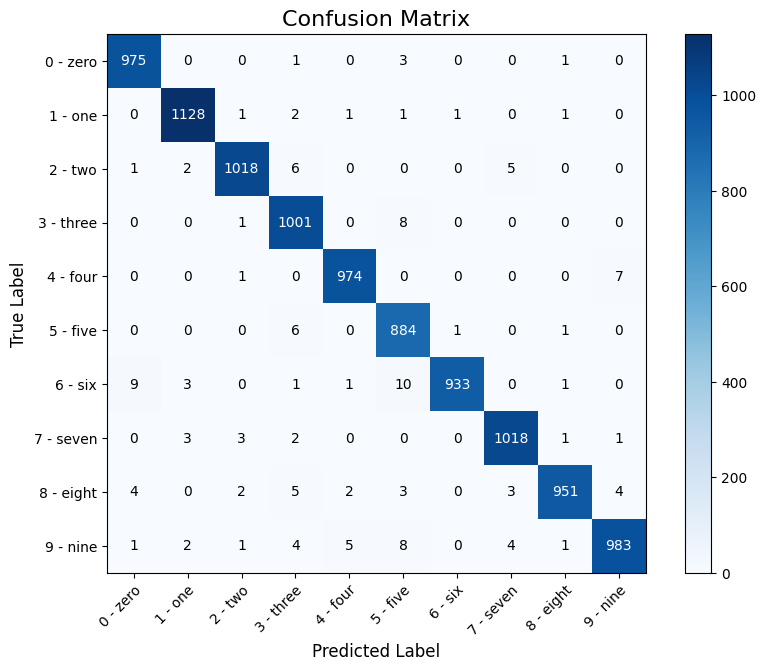

In [18]:
import torch
import matplotlib.pyplot as plt
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
from tqdm.auto import tqdm # Для відображення прогресу

y_preds = []
y_true = []

model_MNIST.eval()
device = next(model_MNIST.parameters()).device

print("Генерація прогнозів...")
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):

    X, y = X.to(device), y.to(device)
    logits = model_MNIST(X)

    pred_labels = torch.argmax(torch.softmax(logits, dim=1), dim=1)

    y_preds.append(pred_labels.cpu())
    y_true.append(y.cpu())

y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_true)


confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor, target=y_true_tensor)


fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7),
    colorbar=True
)

plt.title("Confusion Matrix", fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [19]:
correct = torch.eq(y_pred_tensor, y_true_tensor).sum().item()
total = len(y_true_tensor)

acc = (correct / total) * 100
print(f"Правильно передбачено: {correct} з {total}")
print(f"Точність: {acc:.2f}%")

Правильно передбачено: 9865 з 10000
Точність: 98.65%


## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

In [20]:
wrong_predictions = []

model_MNIST.eval()
device = next(model_MNIST.parameters()).device

with torch.inference_mode():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_MNIST(images)
        preds = outputs.argmax(dim=1)

        wrong_mask = preds != labels

        wrong_indices = torch.nonzero(wrong_mask, as_tuple=True)[0]

        for idx in wrong_indices:
            if len(wrong_predictions) >= 9:
                break

            wrong_predictions.append({
                "image": images[idx].cpu(),
                "pred": preds[idx].item(),
                "true": labels[idx].item()
            })

        if len(wrong_predictions) >= 9:
            break

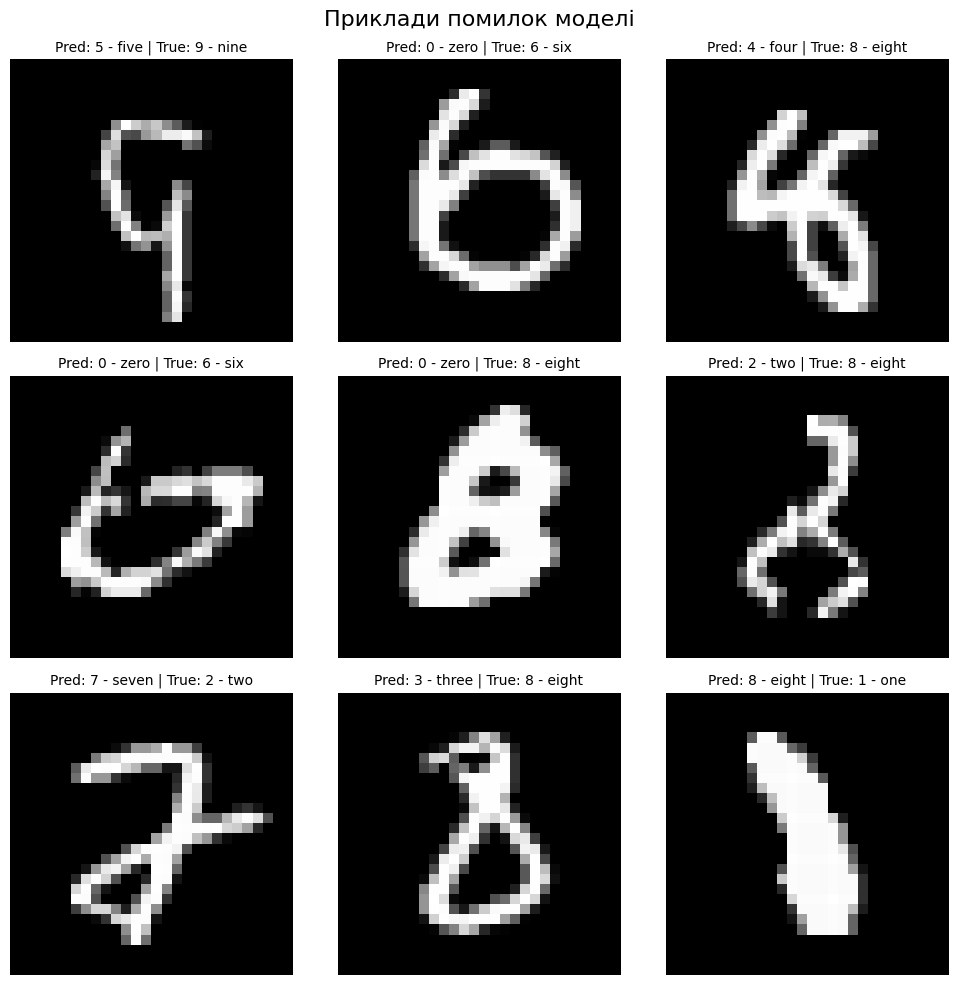

In [21]:
if len(wrong_predictions) < 9:
    print(f"Модель працює занадто добре! Знайдено лише {len(wrong_predictions)} помилок.")
else:
    plt.figure(figsize=(10, 10))
    for i, item in enumerate(wrong_predictions):
        plt.subplot(3, 3, i + 1)

        plt.imshow(item["image"].squeeze(), cmap="gray")

        pred_label = class_names[item["pred"]]
        true_label = class_names[item["true"]]

        plt.title(f"Pred: {pred_label} | True: {true_label}",fontsize=10)
        plt.axis(False)

    plt.suptitle("Приклади помилок моделі", fontsize=16)
    plt.tight_layout()
    plt.show()

**Спостереження:**

Модель показує досить високу точність впізнавання цифр 98.64%.

Помилки моделі можуть бути через:
- незрозумілі навіть для людини цифри (1 в другому ряду або 2 в третьому)
- схожіть між цифрами (0 і 6)
- дивна форма зображень, яка не дає точно визначити (9 і 5, 8 і 4)  


## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [22]:
input_tensor = torch.randn(1, 3, 64, 64)
print(f"Вхідний розмір зображення: {input_tensor.shape}\n")

test_kernel_sizes = [3, 5, 9, 15, 31]

for k_size in test_kernel_sizes:
    conv_layer = nn.Conv2d(
        in_channels=3,
        out_channels=16,
        kernel_size=k_size,
        stride=1,
        padding=0
    )

    output_tensor = conv_layer(input_tensor)
    print(f"kernel_size = {k_size:<2}    Вихідний розмір: {output_tensor.shape}")

Вхідний розмір зображення: torch.Size([1, 3, 64, 64])

kernel_size = 3     Вихідний розмір: torch.Size([1, 16, 62, 62])
kernel_size = 5     Вихідний розмір: torch.Size([1, 16, 60, 60])
kernel_size = 9     Вихідний розмір: torch.Size([1, 16, 56, 56])
kernel_size = 15    Вихідний розмір: torch.Size([1, 16, 50, 50])
kernel_size = 31    Вихідний розмір: torch.Size([1, 16, 34, 34])


**Спостереження:**

Чим більший kernel_size, тим меншим стає вихідне зображення. Це відбувається тому, що згортка без відступів (padding = 0) не може обчислити значення по краях зображення.